Sebelum masuk ke detail pemrosesan, kami mengambil keputusan strategis untuk memuat ulang data mentah (raw data) dari awal, alih-alih menggunakan dataframe yang sudah dimodifikasi pada tahap EDA. Keputusan ini didasari oleh prinsip pemisahan tujuan (separation of concerns). Tahap EDA pada dasarnya bersifat sangat eksploratif; banyak modifikasi, pengelompokan (binning), atau penghapusan baris yang dilakukan murni untuk mempermudah visualisasi grafik. Jika data "bekas" eksplorasi ini langsung diberikan ke dalam algoritma, risiko terjadinya data leakage (kebocoran informasi) dan bias akan sangat tinggi. Dengan memulai kembali dari data mentah, kami dapat membangun pipeline pembersihan yang ketat, terstandarisasi khusus untuk kebutuhan training Machine Learning, serta menjamin reproducibility (keterulangan) kode agar berjalan sempurna tanpa error.

# Import Libraries
Pada tahap ini, kami menginisialisasi seluruh pustaka (libraries) yang akan menjadi mesin utama pengolahan data dan pemodelan, seperti Pandas untuk manipulasi dataframe dan Scikit-Learn untuk algoritma Machine Learning.

In [1]:
import pandas as pd #Untuk manipulasi data
import numpy as np #Untuk operasi matematika
import matplotlib.pyplot as plt #untuk visualisasi data
import seaborn as sns #untuk visualisasi data

pd.set_option('display.max_columns', None) #Menampilkan seluruh kolom DataFrame tanpa batasan pemotongan visual

# Memuat Dataset
Memastikan integritas sumber data dengan memuat dataset transaksi secara langsung melalui tautan repository GitHub resmi yang telah ditetapkan pada panduan kompetisi. Hal ini menjamin bahwa model dibangun di atas data yang valid.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv')
df

C:\Users\Yosuke\AppData\Local\Temp\ipykernel_16228\2419774282.py:1: DtypeWarning: Columns (3,19,23,24,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv')


,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Tgl Lahir,Agama,Pekerjaan,umur,dp aktual,cicilan,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,tgl mohon,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1992-03-03 0:00:00,1,2e,27.0,Rp 21.000.000,Rp 8.600.000,MC,Balikpapan,BREEZ SERIES,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02-01-2019,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1991-04-27 0:00:00,1,2b,28.0,87800000,20600000,MC,Balikpapan,BREEZ SERIES,3 jt up,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02012019,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1982-01-04 0:00:00,1,4b,37.0,Rp 0,Rp 0,MH,Balikpapan,SCOOTY SERIES,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1997-06-26 0:00:00,1,11,22.0,0,0,MH,Balikpapan,SCOOTY SERIES,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1996-07-12 0:00:00,1,2e,23.0,21000000,12200000,MH,Balikpapan,SCOOTY SERIES,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02-01-2019,6471-6400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319973,CUST-122157,WARU,WARU,76284,1.0,10440.0,N,N,1,2006-01-06 0:00:00,1,2e,20.0,Rp 0,Rp 0,BK,PPU,BREEZ SPORT,krg 1 jt,6409.0,AT LOW,MM,22550000.0,2025,NaN,NaN,31122025,6409-6400
319974,CUST-133749,WARU,WARU,76284,2.0,1587.0,1,2,2,1992-09-18 0:00:00,1,2e,34.0,Rp 1.600.000,1530000,BW,PPU,BREEZ STREET,1 - 2 juta,6409.0,AT LOW,MO,21810000.0,2025,NaN,NaN,31-12-2025,6409-6400
319975,CUST-253560,WARU,WARU,76284,2.0,1587.0,1,3,1,1988-07-25 0:00:00,1,2e,38.0,3100000,1355000,WH,PPU,BREEZ STREET,3 jt up,6409.0,AT LOW,MO,21810000.0,2025,NaN,NaN,31122025,6409-6400
319976,CUST-133980,WARU,WARU,76284,2.0,6481.0,1,2,2,2005-09-24 0:00:00,1,2e,21.0,Rp 1.800.000,Rp 1.882.000,CW,Balikpapan,SCOOTY SERIES,1 - 2 jt,6409.0,AT MID,MT,24310000.0,2025,NaN,NaN,31122025,6409-6400


# Data Cleaning
Pada tahap pembersihan data ini, kami melakukan penyaringan baris dan penghapusan kolom secara selektif. Keputusan ini diambil berdasarkan kualitas data yang diamati pada tahap eksplorasi sebelumnya, serta pertimbangan teknis agar algoritma Machine Learning dapat belajar dengan optimal tanpa gangguan noise atau informasi yang menyesatkan.

In [3]:
df = df.dropna(subset=['Customer ID']).reset_index(drop=True) 
df = df.drop(columns = ['tahun rakit', 'DLR group', 'tgl cetak']).reset_index(drop=True) 
df = df.drop(columns=['Tgl Lahir', 'tgl mohon']) 
df = df.drop(columns=['range dp']) 
df = df.iloc[:-1].reset_index(drop=True)

# Data Formatting
Tahap penyeragaman format data ini berfokus pada perbaikan inkonsistensi input dan penyesuaian tipe data agar sesuai dengan karakteristik masing-masing fitur. Langkah ini sangat krusial untuk mencegah algoritma salah menafsirkan data di kemudian hari, misalnya memperlakukan kode kategori sebagai nilai matematis yang bisa dijumlahkan.

In [4]:
tipe_pembayaran = { #Mengubah angka 1 di kolom cash/credit menjadi cash dan angka 2 menjadi credit, untuk memudahkan visualisasi
    1 : 'Cash',
    2 : 'Credit'
}

df['Cash/Credit'] = df['Cash/Credit'].map(tipe_pembayaran)

df.loc[df['Cash/Credit'] == 'Cash', 'Tenor'] = 'N' #Memastikan bahwa jika pembayaran tunai, maka tenor otomatis jadi 'N' (Non-Installment)

#Mengubah tipe data jadi string karena isinya kode kategori agar tidak dihitung secara matematis, tapi tetap bisa dihitung frekuensinya saja
df['Kode Dealer'] = df['Kode Dealer'].astype(str)

#Kolom yang berisi nilai uang, kita ubah ke numerik setelah dibersihkan dari simbol dan spasi
kolom_uang = ['dp aktual', 'cicilan'] 

for col in kolom_uang:
    df[col] = df[col].astype(str) #Memastikan semua data di kolom ini adalah string untuk manipulasi teks
    df[col] = df[col].str.replace('Rp', '', case=False) #Menghapus simbol 'Rp' jika ada, case-insensitive
    df[col] = df[col].str.replace(' ', '', regex=False) #Menghapus spasi yang mungkin ada di antara angka
    df[col] = df[col].str.replace('.', '', regex=False) #Menghapus titik yang mungkin digunakan sebagai pemisah ribuan
    df[col] = pd.to_numeric(df[col], errors='coerce') #Mengubah ke numerik, jika ada yang tidak bisa diubah akan menjadi NaN

# Penghapusan baris
df = df[~((df['dp aktual'] == 0) & (df['cicilan'] == 0))].reset_index(drop=True)

#Jika ada nilai dp aktual yang lebih besar dari OTR, maka kita ganti nilainya dengan OTR, karena secara logika tidak mungkin dp aktual lebih besar dari OTR
df['dp aktual'] = np.where(df['dp aktual'] > df['OTR'], df['OTR'], df['dp aktual'])

#Jika DP aktual lebih besar dari 99 persentil, maka dianggap outlier, set ke batas atas persentil 99% untuk DP sekarang
batas_atas_dp = df['dp aktual'].quantile(0.99)

df['dp aktual'] = np.where(df['dp aktual'] > batas_atas_dp, batas_atas_dp, df['dp aktual'])

# Target Engineering

In [5]:
df['total_transaksi'] = df.groupby('Customer ID')['Customer ID'].transform('count')
df['repeat_order'] = np.where(df['total_transaksi'] > 1, 1, 0) #-> 1 jika repeat order, 0 jika tidak

df = df.drop_duplicates(subset=['Customer ID'], keep='first').copy()
df = df.drop(columns=['total_transaksi'])

In [6]:
df.columns

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Cash/Credit',
       'Kode Dealer', 'Finance Company', 'Tenor', 'Gender', 'Agama',
       'Pekerjaan', 'umur', 'dp aktual', 'cicilan', 'warna', 'dealer',
       'type series', 'wilayah', '9 segment', 'kode motor', 'OTR',
       'Kode Kota-Provinsi', 'repeat_order'],
      dtype='object')

# Penentuan Fitur Yang Akan Dipakai

Setelah menyusun variabel target, kami melakukan penyeleksian fitur untuk mengurangi dimensi dataset. Proses ini bertujuan membuang kolom kolom yang tidak memiliki daya prediktif terhadap perilaku repeat order, mencegah redundansi, serta memastikan model yang dibangun beroperasi secara etis tanpa bias demografi.
Fitur fitur yang dieliminasi didasarkan pada lima argumentasi teknis dan bisnis berikut:
1. Penghapusan Customer ID: Kolom Customer ID ini dibuang karena algoritma klasifikasi tidak dapat mengekstrak pola general dari data yang sepenuhnya spesifik per individu. Memaksakan fitur ini masuk ke dalam pemodelan justru berisiko tinggi memicu overfitting di mana model hanya menghafal data, bukan memahaminya.
2. Kami secara sadar mengeleminasi kolom gender dan agama untuk mencegah bias. Keputusan ini berlandaskan pada prinsip etika kecerdasan buatan untuk memastikan model prediksi murni menilai probabilitas repeat order berdasarkan profil finansial dan riwayat transaksi, bukan menciptakan diskriminasi terhadap kelompok tertentu.
3. Kita memutuskan untuk membuang data lokasi yang terlalu spesifik seperti Kelurahan, Kecamatan, dan Kode POS karena variasi isinya sangat banyak. Terlalu banyak variasi unik di dalam satu kolom justru tidak terlalu berdampak pada kemampuan algoritma dalam memprediksi peluang repeat order. Sebagai gantinya, kita merasa gambaran asal daerah pelanggan sudah terwakili dengan cukup baik dan ringkas oleh fitur wilayah yang cakupannya lebih luas.
4. Kami mengeliminasi tiga fitur, yaitu kode dealer, kode motor, kode kota-provinsi. Tabel ini dibuang karena sifatnya yang redundant. Informasi lokasi, jenis barang, dan titik transaksi telah diwakili dengan jauh lebih jelas dan ringkas oleh fitur teks nama dealer, nama wilayah, dan tipe kendaraan.
5. Kami juga membuang preferensi estetika yaitu kolom Warna. Secara logika bisnis, warna kendaraan murni merupakan preferensi visual yang bersifat subjektif. Pemilihan warna pada transaksi pertama tidak memiliki korelasi kausalitas yang masuk akal terhadap kemampuan finansial maupun intensi pelanggan untuk melakukan repeat order di masa depan.

In [7]:
kolom_buang = [
    'Customer ID', 
    'Kelurahan', 
    'Kecamatan',
    'Kode POS', 
    'warna', 
    'Kode Dealer', 
    'kode motor', 
    'Gender', 
    'Agama',
    'Kode Kota-Provinsi', 
]

df = df.drop(columns=kolom_buang)

df

,Cash/Credit,Finance Company,Tenor,Pekerjaan,umur,dp aktual,cicilan,dealer,type series,wilayah,9 segment,OTR,repeat_order
0,Credit,4,3,2e,27.0,18685000.0,8600000.0,Balikpapan,BREEZ SERIES,6471,AT LOW,18685000.0,0
1,Credit,1,1,2b,28.0,18685000.0,20600000.0,Balikpapan,BREEZ SERIES,6471,AT LOW,18685000.0,0
2,Credit,1,2,2e,23.0,20775000.0,12200000.0,Balikpapan,SCOOTY SERIES,6471,AT MID,20775000.0,0
3,Credit,1,2,2c,23.0,20775000.0,13500000.0,Balikpapan,SCOOTY SERIES,6471,AT MID,20775000.0,1
4,Credit,1,2,4f,55.0,20775000.0,10500000.0,Balikpapan,SCOOTY SERIES,6471,AT MID,20775000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
181895,Credit,1,3,2e,22.0,1600000.0,1374000.0,Berau,BREEZ SPORT,6405.0,AT LOW,21440000.0,0
181896,Credit,1,1,15,47.0,5150000.0,2569000.0,Berau,SCOOTY SERIES,6405.0,AT MID,26230000.0,0
181898,Credit,1,2,2e,34.0,1600000.0,1530000.0,PPU,BREEZ STREET,6409.0,AT LOW,21810000.0,0
181899,Credit,1,3,2e,38.0,3100000.0,1355000.0,PPU,BREEZ STREET,6409.0,AT LOW,21810000.0,0


# Inisiasi Pembagian Data (Split Train vs Test)
Pada tahap ini, kita membagi dataset menjadi dua bagian independen: 80% sebagai data latih (Training Set) terhadap model, dan 20% sebagai data uji (Testing Set) untuk mengevaluasi kinerja model. Sesuai dengan pedoman kompetisi, kita juga menetapkan parameter random_state=42 agar proses pengacakan data ini bersifat konsisten dan dapat direproduksi ulang di masa mendatang.

Hal yang paling krusial dari tahapan ini adalah posisinya. Kita wajib melakukan split data sebelum masuk ke tahap imputasi nilai kosong atau perhitungan statistik lanjutan untuk menghindari Data Leakage (Kebocoran Data). Data leakage terjadi ketika informasi dari data uji secara tidak sengaja ikut terlibatkan dalam proses persiapan data latih. Sebagai contoh, apabila kalkulasi statistik agregat seperti pencarian nilai rata-rata, median, maupun persentil dilakukan pada keseluruhan dataset sebelum dipisah, maka metrik dari data uji akan terdistribusi dan mendistorsi data latih. Akibatnya, model akan menghasilkan evaluasi yang bias, seolah-olah memiliki akurasi yang sangat tinggi saat fase training, namun nyatanya gagal menggeneralisasi pola ketika dihadapkan pada data riil yang belum pernah diobservasi.

In [8]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['repeat_order'])
y = df['repeat_order']
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42) # pembagian nya train 80% dan test 20%

# Penanganan Outlier
Pada tahap ini, kita memfilter nilai ekstrem (outlier) sekaligus memastikan seluruh data mematuhi logika bisnis pembiayaan yang nyata. Untuk mencegah kebocoran data (data leakage), seluruh kalkulasi batas statistik (seperti kuantil 99) dihitung secara eksklusif menggunakan data latih (X_train) sebelum diaplikasikan ke data uji (X_test).

In [9]:
#Mengatasi outlier umur
X_train['umur'] = np.where((X_train['umur'] < 17) | (X_train['umur'] > 100), np.nan, X_train['umur'])
X_test['umur']  = np.where((X_test['umur'] < 17)  | (X_test['umur'] > 100), np.nan, X_test['umur'])


#Mengatasi outlier OTR
batas_atas_otr_train = X_train['OTR'].quantile(0.99)
X_train['OTR'] = np.where(X_train['OTR'] > batas_atas_otr_train, batas_atas_otr_train, X_train['OTR'])
X_test['OTR']  = np.where(X_test['OTR'] > batas_atas_otr_train, batas_atas_otr_train, X_test['OTR'])

In [10]:
#Normalisasi dp aktual dan OTR agar tidak ada nilai dp aktual yang lebih besar dari OTR
X_train['dp aktual'] = np.where(X_train['dp aktual'] > X_train['OTR'], X_train['OTR'], X_train['dp aktual'])
X_test['dp aktual']  = np.where(X_test['dp aktual']  > X_test['OTR'],  X_test['OTR'],  X_test['dp aktual'])

#Mengatasi outlier dp aktual
batas_atas_dp_train = X_train['dp aktual'].quantile(0.99)
X_train['dp aktual'] = np.where(X_train['dp aktual'] > batas_atas_dp_train, batas_atas_dp_train, X_train['dp aktual'])
X_test['dp aktual']  = np.where(X_test['dp aktual']  > batas_atas_dp_train, batas_atas_dp_train, X_test['dp aktual'])

In [11]:
#Jika DP = OTR (Lunas), maka cicilan WAJIB 0
X_train['cicilan'] = np.where(X_train['dp aktual'] == X_train['OTR'], 0, X_train['cicilan'])
X_test['cicilan']  = np.where(X_test['dp aktual']  == X_test['OTR'],  0, X_test['cicilan'])

#Melakukan validasi silang antara kolom Cash/Credit dengan dp aktual dan OTR, untuk memastikan tidak ada inkonsistensi tipe pembayaran dengan nilai dp aktual dan OTR
if 'Cash/Credit' in X_train.columns:
    #Mengubah jd cash jika dp aktual == otr, atau jadi credit jika dp != aktual
    X_train['Cash/Credit'] = np.where(X_train['dp aktual'] == X_train['OTR'], 'Cash', 'Credit')
    X_test['Cash/Credit']  = np.where(X_test['dp aktual']  == X_test['OTR'],  'Cash', 'Credit')

    #Mengubah tenor menjadi N jika pembayaran cash
    X_train['Tenor'] = np.where(X_train['Cash/Credit'] == 'Cash', 'N', X_train['Tenor'])
    X_test['Tenor']  = np.where(X_test['Cash/Credit'] == 'Cash', 'N', X_test['Tenor'])

#Jika Cicilan > OTR, data jadi NaN untuk diimputasi nanti, karena secara logika tidak masuk akal.
X_train['cicilan'] = np.where(X_train['cicilan'] > X_train['OTR'], np.nan, X_train['cicilan'])
X_test['cicilan']  = np.where(X_test['cicilan'] > X_test['OTR'], np.nan, X_test['cicilan'])

modus_leasing_train = X_train[X_train['Finance Company'] != 'N']['Finance Company'].mode()[0]
modus_tenor_train = X_train[X_train['Tenor'] != 'N']['Tenor'].mode()[0]

#Mencari kondisi untuk kredit bocor, yaitu yang tipe pembayarannya credit, tapi leasing dan tenornya N
kondisi_kredit_bocor_train = (X_train['Cash/Credit'] == 'Credit') & (X_train['Finance Company'] == 'N') & (X_train['Tenor'] == 'N')
kondisi_kredit_bocor_test = (X_test['Cash/Credit'] == 'Credit') & (X_test['Finance Company'] == 'N') & (X_test['Tenor'] == 'N')

#Menimpa nilai 'N' dengan modus dari X_train
X_train.loc[kondisi_kredit_bocor_train, 'Finance Company'] = modus_leasing_train
X_train.loc[kondisi_kredit_bocor_train, 'Tenor'] = modus_tenor_train

X_test.loc[kondisi_kredit_bocor_test, 'Finance Company'] = modus_leasing_train
X_test.loc[kondisi_kredit_bocor_test, 'Tenor'] = modus_tenor_train

#Mencari batas atas (persentil 99) dan median HANYA dari X_train
batas_atas_cicilan_train = X_train['cicilan'].quantile(0.99)

#Menerapkan capping
X_train['cicilan'] = np.where(X_train['cicilan'] > batas_atas_cicilan_train, batas_atas_cicilan_train, X_train['cicilan'])
X_test['cicilan']  = np.where(X_test['cicilan'] > batas_atas_cicilan_train, batas_atas_cicilan_train, X_test['cicilan'])


In [12]:
X_train.isna().sum()
X_test.isna().sum()

Cash/Credit           0
Finance Company       1
Tenor                 0
Pekerjaan             0
umur               5642
dp aktual           116
cicilan             248
dealer                0
type series           0
wilayah               0
9 segment             0
OTR                   0
dtype: int64

# Penanganan NaN
Pada tahap ini, kita menangani nilai-nilai kosong (NaN) yang ada di dalam dataset menggunakan modul SimpleImputer dari Scikit-Learn. Strategi pengisian dibedakan berdasarkan tipe datanya: nilai median digunakan untuk menambal kolom numerik karena sifatnya yang lebih stabil dan kebal terhadap outlier, sedangkan nilai modus (most frequent) digunakan untuk mengisi kekosongan pada kolom kategorikal. Proses pembelajaran nilai median dan modus (fit) dieksekusi murni hanya menggunakan data latih (X_train). Parameter statistik yang didapat dari data latih tersebut barulah diaplikasikan (transform) untuk menimpa nilai NaN, baik pada data latih itu sendiri maupun pada data uji (X_test).

In [13]:
from sklearn.impute import SimpleImputer #SimpleImputer untuk mengisi nilai NaN dengan strategi tertentu, seperti median untuk numerik dan modus untuk kategorikal
import pandas as pd #pandas untuk manipulasi data

#Memisahkan nama kolom berdasarkan tipe datanya
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

#Membuat imputer untuk kolom numerik dan kategorikal
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

#Mengisi nilai NaN di kolom numerik dengan median dari X_train, dan mengisi nilai NaN di kolom kategorikal dengan modus (most_frequent) dari X_train
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])

#Hanya transform di X_test (Isi NaN di Test pakai aturan dari Train)
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

#Mengisi nilai NaN di kolom kategorikal dengan modus (most_frequent) dari X_train
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

#Hanya transform di X_test
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print("Jumlah NaN di X_train setelah imputasi:", X_train.isna().sum().sum())
print("Jumlah NaN di X_test setelah imputasi:", X_test.isna().sum().sum())


Jumlah NaN di X_train setelah imputasi: 0
Jumlah NaN di X_test setelah imputasi: 0


# Rekayasa Fitur (Feature Engineering)
Pada tahap ini, kita mengekstraksi variabel prediktif baru dari kombinasi data yang sudah ada untuk memperkaya kemampuan model dalam mengenali pola. Agar konsisten, seluruh tahapan transformasi dibungkus ke dalam satu fungsi terpusat yang diaplikasikan secara serentak pada data latih dan data uji.
Adapun penambahan fitur baru yang kita rancang meliputi:
1. Rasio DP: Kita membagi nominal uang muka (DP) dengan harga total motor (OTR). Tujuannya untuk melihat persentase DP yang dibayarkan, yang bisa menjadi patokan kemampuan finansial pembeli.
2. Mengubah Tenor Jadi Angka Bulan: Awalnya, data lama cicilan masih berbentuk kode teks (1, 2, 3). Kita mengubah kode tersebut menjadi perkiraan angka bulan yang sebenarnya (12, 24, dan 36 bulan). Khusus untuk yang bayar lunas, angkanya otomatis menjadi 0. Setelah diubah, kolom kode yang lama langsung kita hapus.
3. Perkiraan Total Bayar & Bunga: Dengan menggunakan angka bulan dari langkah sebelumnya, kita menghitung total uang yang sebenarnya dikeluarkan pembeli (DP ditambah total cicilan). Dari situ, kita bisa menghitung berapa beban bunga yang mereka tanggung. Pembeli tunai akan otomatis memiliki beban bunga 0.
4. Daripada membiarkan algoritma menganalisa angka umur yang terlalu bervariasi satu per satu, kita mengelompokkan pelanggan ke dalam rentang generasi (Gen Z, Milenial, dan Gen X/Boomer). Hal ini mempermudah model untuk membaca pola belanja berdasarkan kelompok usia.

In [14]:
def feature_engineering(df):
    #Membuat copy agar data asli aman
    df_fe = df.copy()
    
    #Membuat fitur baru Rasio DP
    df_fe['Rasio_DP'] = df_fe['dp aktual'] / df_fe['OTR']
    
    #Membuat fitur tenor dalam bulan dari kolom Tenor yang awalnya kategori (1,2,3,N)
    df_fe['Tenor'] = df_fe['Tenor'].astype(str).str.strip()
    
    #Membuat kamus (dictionary) estimasi bulan
    map_tenor = {
        '1': 12,  #< 1 tahun diasumsikan tenor pendek standar 12 bulan
        '2': 24,  #1-2 tahun diasumsikan 24 bulan
        '3': 36,  #> 2 tahun diasumsikan tenor panjang standar 36 bulan
        'N': 0    #Cash / Tidak ada tenor
    }
    
    #Membuat kolom bantuan 'Tenor_Bulan' dimana tipe data jadi float/int otomatis
    df_fe['Tenor_Bulan'] = df_fe['Tenor'].map(map_tenor).fillna(0)
    
   
    #Membuat fitur estimasi Total Bayar dan Beban Bunga berdasarkan logika pembayaran cash atau kredit. Yang cash otomatis cicilan 0 dan tenor 0.
    df_fe['Total_Bayar_Estimasi'] = df_fe['dp aktual'] + (df_fe['cicilan'] * df_fe['Tenor_Bulan'])
    df_fe['Beban_Bunga_Estimasi'] = df_fe['Total_Bayar_Estimasi'] - df_fe['OTR']
    
    #Mengelompokkan umur ke dalam kategori generasi berdasarkan rentang umur yang umum digunakan
    kondisi_umur = [
        (df_fe['umur'] <= 27),                        # Gen Z
        (df_fe['umur'] > 27) & (df_fe['umur'] <= 43), # Milenial
        (df_fe['umur'] > 43)                          # Gen X & Boomer
    ]
    pilihan_generasi = ['Gen_Z', 'Milenial', 'Gen_X_Boomer']
    df_fe['Generasi'] = np.select(kondisi_umur, pilihan_generasi, default='Unknown')
    
    return df_fe

X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

print(f"Total kolom setelah feature engineering: {X_train.shape[1]}")


Total kolom setelah feature engineering: 17


In [15]:
X_train 


,Cash/Credit,Finance Company,Tenor,Pekerjaan,umur,dp aktual,cicilan,dealer,type series,wilayah,9 segment,OTR,Rasio_DP,Tenor_Bulan,Total_Bayar_Estimasi,Beban_Bunga_Estimasi,Generasi
122542,Credit,1,3,15,21.0,6000000.0,1619000.0,PPU,PXE,6409,AT HIGH,3.518000e+07,0.170551,36.0,64284000.0,2.910400e+07,Gen_Z
105716,Credit,4,2,11,33.0,30000000.0,16830000.0,PPU,VAREX 160,6409,AT HIGH,2.960000e+08,0.101351,24.0,433920000.0,1.379200e+08,Milenial
126924,Credit,1,2,3,56.0,600000.0,1500000.0,Tarakan,BREEZ STREET,6571,AT LOW,2.116000e+07,0.028355,24.0,36600000.0,1.544000e+07,Gen_X_Boomer
75277,Cash,1,N,8,57.0,30890000.0,0.0,Balikpapan,VAREX 160,6471,AT HIGH,3.089000e+07,1.000000,0.0,30890000.0,0.000000e+00,Gen_X_Boomer
3478,Cash,1,N,5,23.0,17440000.0,0.0,Nunukan,BREEZ SERIES,6504,AT LOW,1.744000e+07,1.000000,0.0,17440000.0,0.000000e+00,Gen_Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135500,Credit,1,2,2d,45.0,1500000.0,1380000.0,Paser,BREEZ STREET,6401,AT LOW,2.096000e+07,0.071565,24.0,34620000.0,1.366000e+07,Gen_X_Boomer
115776,Credit,1,2,2e,33.0,39000000.0,25000000.0,Bulungan,KRF150L,6502,SPORT MID,3.713880e+08,0.105011,24.0,639000000.0,2.676120e+08,Milenial
150384,Credit,1,3,4e,25.0,1600000.0,1220000.0,Bulungan,BREEZ SPORT,6502,AT LOW,2.164000e+07,0.073937,36.0,45520000.0,2.388000e+07,Gen_Z
169195,Credit,2,2,8,24.0,4000000.0,1960000.0,Paser,VAREX 160,6401.0,AT HIGH,3.377000e+07,0.118448,24.0,51040000.0,1.727000e+07,Gen_Z


In [16]:
X_train = X_train.drop(columns = ['Tenor'])
X_test = X_test.drop(columns = ['Tenor'])

Kita menghapus kolom Tenor yang asli untuk menghindari informasi redundant. Seluruh informasi dari kolom ini sudah terwakili sepenuhnya oleh fitur baru yang kita buat (Tenor_Label), sehingga kolom lamanya sudah tidak diperlukan lagi oleh model.

In [17]:
X_train.columns

Index(['Cash/Credit', 'Finance Company', 'Pekerjaan', 'umur', 'dp aktual',
       'cicilan', 'dealer', 'type series', 'wilayah', '9 segment', 'OTR',
       'Rasio_DP', 'Tenor_Bulan', 'Total_Bayar_Estimasi',
       'Beban_Bunga_Estimasi', 'Generasi'],
      dtype='object')

# Encoding (Transformasi Teks ke Numerik)
Pada tahap ini, kita mengubah seluruh sisa data yang masih berformat teks (kategorikal) menjadi angka agar dapat diproses oleh algoritma Machine Learning. Untuk mencegah kebocoran data, semua aturan pengubahan angka ini murni kita ambil dari pola data latih (X_train) saja, yang kemudian kita terapkan pada data uji (X_test).
Kita menggunakan kombinasi tiga strategi encoding sekaligus agar model bisa belajar dengan efisien:
1. Pengelompokan kategori langka khusus untuk kolom perusahaan pembiayaan (Finance Company), variasinya sangat banyak namun beberapa nama perusahaan sangat jarang muncul. Kita menggabungkan nama perusahaan yang frekuensi kemunculannya di bawah 1.000 ke dalam satu kategori umum bernama 'Other'. Hal ini mencegah algoritma menghafal data yang terlalu kecil dan membantunya fokus pada pola dari perusahaan besar.
2. Frequency encoding untuk kolom dengan variasi teks yang sangat banyak seperti jenis pekerjaan, nama dealer, seri motor, dan wilayah. Kita mengubah teks tersebut menjadi angka berdasarkan jumlah kemunculannya di data latih. Pendekatan ini jauh lebih hemat memori dibandingkan harus memecahnya menjadi ratusan kolom baru.
3. One-hot encoding untuk kolom dengan variasi kategori yang sedikit seperti tipe pembayaran, segmen motor, generasi umur, dan nama perusahaan pembiayaan yang sudah disederhanakan tadi, kita memecahnya menjadi matriks biner bernilai 1 dan 0.

In [18]:
from sklearn.preprocessing import OneHotEncoder #OneHotEncoder untuk mengubah kategori menjadi fitur biner (0/1) untuk setiap kategori unik

def apply_encoding_pro(X_train, X_test):
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()
    
    #Mengelompokkan kategori langka 
    #Kita hitung frekuensi kategori HANYA dari X_train untuk menentukan mana yang langka.
    counts_finance = X_train_enc['Finance Company'].value_counts()
    
    #Mengambil nama-nama perusahaan yang frekuensinya di bawah 1000
    langka = counts_finance[counts_finance < 1000].index
    
    #Mengganti nama perusahaan yang langka menjadi 'Other' di Train dan Test
    X_train_enc['Finance Company'] = X_train_enc['Finance Company'].replace(langka, 'Other')
    X_test_enc['Finance Company']  = X_test_enc['Finance Company'].replace(langka, 'Other')
    #Mengganti kategori aneh baru di Test yang tidak ada di Train dengan 'Other'
    X_test_enc['Finance Company'] = X_test_enc['Finance Company'].apply(lambda x: x if x in counts_finance.index else 'Other')

    #Melakukan frequency encoding untuk kolom-kolom dengan banyak kategori unik 
    high_card_cols = ['Pekerjaan', 'dealer', 'type series', 'wilayah']
    for col in high_card_cols:
        frekuensi_train = X_train_enc[col].value_counts()
        X_train_enc[col] = X_train_enc[col].map(frekuensi_train)
        X_test_enc[col]  = X_test_enc[col].map(frekuensi_train).fillna(0)

   #Melakukan one-hot encoding untuk kolom-kolom dengan jumlah kategori yang lebih sedikit
    low_card_cols = ['Cash/Credit', 'Finance Company', '9 segment', 'Generasi']
    
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    train_ohe_array = ohe.fit_transform(X_train_enc[low_card_cols])
    ohe_col_names = ohe.get_feature_names_out(low_card_cols)
    train_ohe_df = pd.DataFrame(train_ohe_array, columns=ohe_col_names, index=X_train_enc.index)
    
    test_ohe_array = ohe.transform(X_test_enc[low_card_cols])
    test_ohe_df = pd.DataFrame(test_ohe_array, columns=ohe_col_names, index=X_test_enc.index)
    
    X_train_enc = pd.concat([X_train_enc.drop(columns=low_card_cols), train_ohe_df], axis=1)
    X_test_enc  = pd.concat([X_test_enc.drop(columns=low_card_cols),  test_ohe_df], axis=1)

    return X_train_enc, X_test_enc

#Mengeksekusi fungsi encoding ke data kita
X_train, X_test = apply_encoding_pro(X_train, X_test)

print(f"Total fitur sekarang: {X_train.shape[1]}")

Total fitur sekarang: 36


In [19]:
X_train

,Pekerjaan,umur,dp aktual,cicilan,dealer,type series,wilayah,OTR,Rasio_DP,Tenor_Bulan,Total_Bayar_Estimasi,Beban_Bunga_Estimasi,Cash/Credit_Cash,Cash/Credit_Credit,Finance Company_1,Finance Company_11,Finance Company_13,Finance Company_2,Finance Company_3,Finance Company_4,Finance Company_5,Finance Company_9,Finance Company_Other,9 segment_AT HIGH,9 segment_AT LOW,9 segment_AT MID,9 segment_CUB HIGH,9 segment_CUB LOW,9 segment_CUB MID,9 segment_EV AT HIGH,9 segment_SPORT HIGH,9 segment_SPORT LOW,9 segment_SPORT MID,Generasi_Gen_X_Boomer,Generasi_Gen_Z,Generasi_Milenial
122542,8276,21.0,6000000.0,1619000.0,10422,5491,3153,3.518000e+07,0.170551,36.0,64284000.0,2.910400e+07,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
105716,10601,33.0,30000000.0,16830000.0,10422,8277,7990,2.960000e+08,0.101351,24.0,433920000.0,1.379200e+08,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
126924,615,56.0,600000.0,1500000.0,13259,8759,3620,2.116000e+07,0.028355,24.0,36600000.0,1.544000e+07,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
75277,24537,57.0,30890000.0,0.0,44816,8277,13014,3.089000e+07,1.000000,0.0,30890000.0,0.000000e+00,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3478,10505,23.0,17440000.0,0.0,5277,15359,3945,1.744000e+07,1.000000,0.0,17440000.0,0.000000e+00,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135500,4454,45.0,1500000.0,1380000.0,19441,8759,13692,2.096000e+07,0.071565,24.0,34620000.0,1.366000e+07,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
115776,20461,33.0,39000000.0,25000000.0,9959,3670,2588,3.713880e+08,0.105011,24.0,639000000.0,2.676120e+08,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
150384,5039,25.0,1600000.0,1220000.0,9959,15765,6669,2.164000e+07,0.073937,36.0,45520000.0,2.388000e+07,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
169195,24537,24.0,4000000.0,1960000.0,19441,8277,13692,3.377000e+07,0.118448,24.0,51040000.0,1.727000e+07,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Standarisasi Data (Scalling)

Tahap ini kita lakukan sebagai persiapan akhir sebelum melatih model Machine Learning. Kita perlu menyamakan skala angka pada semua fitur karena rentang nilainya sangat berbeda jauh. Sebagai contoh, harga motor (OTR) berada di angka puluhan juta, sedangkan umur hanya di angka puluhan. Tanpa proses ini, model cenderung hanya fokus pada angka yang besar dan mengabaikan fitur dengan angka kecil yang sebenarnya penting.
Kita memilih StandardScaler (Z-Score) dibandingkan metode lain dengan alasan berikut:
- Lebih Stabil Dibanding MinMaxScaler. Jika MinMaxScaler memeras data ke rentang 0 sampai 1, StandardScaler mengubah data agar memiliki rata-rata 0 dan standar deviasi 1. Kita memilih ini karena lebih cocok untuk algoritma klasifikasi dan lebih aman dalam menjaga pola data.
- Lebih Cocok dengan Penanganan Outlier: Karena sebelumnya kita sudah melakukan pembersihan nilai ekstrem (capping) secara manual, StandardScaler menjadi pilihan yang paling pas untuk menyeimbangkan distribusi data kita.

Secara teknis, kita tetap menjaga agar tidak ada bocoran informasi. Caranya, kita hanya menyuruh mesin belajar dari data train saja. Standar yang didapat dari data train itulah yang kemudian kita pakai untuk mengubah data test, sehingga penilaian model nanti tetap akurat.

In [20]:
#StandardScaler untuk normalisasi fitur numerik agar memiliki mean 0 dan standar deviasi 1
from sklearn.preprocessing import StandardScaler

def apply_scaling(X_train, X_test):
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    scaler = StandardScaler()
    
    #Mengambil semua nama kolom
    kolom_angka = X_train_scaled.columns    
    #Fit and Transform dimana mesin belajar mencari Mean dan Standar Deviasi dari X_train
    X_train_scaled[kolom_angka] = scaler.fit_transform(X_train_scaled[kolom_angka])
    
    #Menerapkan transformasi yang sudah dipelajari dari X_train ke X_test. 
    X_test_scaled[kolom_angka] = scaler.transform(X_test_scaled[kolom_angka])
    
    return X_train_scaled, X_test_scaled

X_train, X_test = apply_scaling(X_train, X_test) #Mengeksekusi fungsi scaling ke data kita


In [21]:
#Mengambil nama-nama kolom yang bertipe numerik 
numerik_kolom = df.select_dtypes(include=['number']).columns.tolist() 
numerik_kolom

['umur', 'dp aktual', 'cicilan', 'OTR', 'repeat_order']

In [22]:
X_train.head()

,Pekerjaan,umur,dp aktual,cicilan,dealer,type series,wilayah,OTR,Rasio_DP,Tenor_Bulan,Total_Bayar_Estimasi,Beban_Bunga_Estimasi,Cash/Credit_Cash,Cash/Credit_Credit,Finance Company_1,Finance Company_11,Finance Company_13,Finance Company_2,Finance Company_3,Finance Company_4,Finance Company_5,Finance Company_9,Finance Company_Other,9 segment_AT HIGH,9 segment_AT LOW,9 segment_AT MID,9 segment_CUB HIGH,9 segment_CUB LOW,9 segment_CUB MID,9 segment_EV AT HIGH,9 segment_SPORT HIGH,9 segment_SPORT LOW,9 segment_SPORT MID,Generasi_Gen_X_Boomer,Generasi_Gen_Z,Generasi_Milenial
122542,-0.574858,-1.325079,-0.760059,-0.470899,-1.089111,-0.923679,-1.199119,-0.326040,-0.895441,1.587130,-0.395959,-0.311807,-0.788670,0.788670,0.578519,-0.195064,-0.095555,-0.284503,-0.135483,-0.236905,-0.194425,-0.105855,-0.107877,2.275866,-0.827094,-0.697312,-0.102849,-0.145571,-0.128351,-0.00747,-0.027675,-0.121202,-0.209602,-0.486235,1.611496,-1.063551
105716,-0.283824,-0.124467,0.677534,1.783317,-1.089111,-0.674167,-0.660162,2.620602,-1.061943,0.678629,1.859257,0.629647,-0.788670,0.788670,-1.728551,-0.195064,-0.095555,-0.284503,-0.135483,4.221106,-0.194425,-0.105855,-0.107877,2.275866,-0.827094,-0.697312,-0.102849,-0.145571,-0.128351,-0.00747,-0.027675,-0.121202,-0.209602,-0.486235,-0.620541,0.940246
126924,-1.533832,2.176706,-1.083518,-0.488534,-0.893981,-0.631000,-1.147084,-0.484432,-1.237579,0.678629,-0.564864,-0.430025,-0.788670,0.788670,0.578519,-0.195064,-0.095555,-0.284503,-0.135483,-0.236905,-0.194425,-0.105855,-0.107877,-0.439393,1.209053,-0.697312,-0.102849,-0.145571,-0.128351,-0.00747,-0.027675,-0.121202,-0.209602,2.056618,-0.620541,-1.063551
75277,1.460629,2.276757,0.730844,-0.710829,1.276521,-0.674167,-0.100368,-0.374506,1.100296,-1.138373,-0.599702,-0.563609,1.267958,-1.267958,0.578519,-0.195064,-0.095555,-0.284503,-0.135483,-0.236905,-0.194425,-0.105855,-0.107877,2.275866,-0.827094,-0.697312,-0.102849,-0.145571,-0.128351,-0.00747,-0.027675,-0.121202,-0.209602,2.056618,-0.620541,-1.063551
3478,-0.295841,-1.124977,-0.074807,-0.710829,-1.442986,-0.039909,-1.110871,-0.526459,1.100296,-1.138373,-0.681763,-0.563609,1.267958,-1.267958,0.578519,-0.195064,-0.095555,-0.284503,-0.135483,-0.236905,-0.194425,-0.105855,-0.107877,-0.439393,1.209053,-0.697312,-0.102849,-0.145571,-0.128351,-0.00747,-0.027675,-0.121202,-0.209602,-0.486235,1.611496,-1.063551


# Pelatihan Model dan Penanganan Ketidakseimbangan Data
Setelah data siap, kita masuk ke tahap pelatihan model. Tantangan utama dalam dataset ini adalah ketidakseimbangan proporsi data, di mana jumlah pelanggan yang tidak melakukan pembelian ulang jauh lebih banyak dibandingkan yang melakukan repeat order. Jika tidak ditangani, model akan cenderung menebak kelas mayoritas dan gagal mengenali pelanggan potensial. Untuk mengatasinya, kita menerapkan strategi Cost-Sensitive Learning. Kita menghitung rasio ketidakseimbangan dan menggunakannya sebagai bobot penalti dalam model. Dengan cara ini, model akan diberikan "punishment" lebih berat jika salah memprediksi pelanggan yang sebenarnya melakukan repeat order.
Kita melatih empat algoritma klasifikasi yang berbeda untuk mencari performa terbaik:
1. Logistic Regression sebagai model dasar (baseline) yang sederhana dan mudah diinterpretasi.
2. Random Forest, algoritma berbasis kumpulan pohon keputusan (ensemble) yang tangguh terhadap data kompleks.
3. XGBoost: Model gradient boosting yang dikenal sangat cepat dan memiliki akurasi tinggi.
4. LightGBM: Versi boosting yang lebih efisien dalam menangani data skala besar dengan penggunaan memori yang lebih rendah.

In [23]:
from sklearn.linear_model import LogisticRegression #Mengimpor Logistic Regression sebagai model dasar (baseline) karena prosesnya cepat dan gampang diinterpretasi
from sklearn.ensemble import RandomForestClassifier #Mengimpor Random Forest untuk menangkap pola data yang lebih kompleks dan hubungan antar fitur yang tidak searah
from xgboost import XGBClassifier #Mengimpor XGBoost untuk meningkatkan akurasi melalui teknik boosting yang kuat dan fleksibel dalam penyesuaian parameter
from lightgbm import LGBMClassifier #Mengimpor LightGBM karena performanya sangat efisien pada data besar dan handal dalam mengolah berbagai tipe fitur secara cepat
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score #Parameter untuk evaluasi model

#Menghitung Rasio Ketidakseimbangan (Pinalti) 
jumlah_kelas_0 = y_train.value_counts()[0]
jumlah_kelas_1 = y_train.value_counts()[1]
rasio_imbalance = jumlah_kelas_0 / jumlah_kelas_1

print(f"Proporsi Data: {jumlah_kelas_0} (Tidak Repeat) vs {jumlah_kelas_1} (Repeat)")
print(f"Model akan diberi punishment {rasio_imbalance:.2f}x lipat jika salah menebak pelanggan Repeat Order\n")

#Melakukan update model 
models_balanced = {
    #Logistic Regression & Random Forest pakai parameter class_weight='balanced'
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    
    #XGBoost pakai parameter scale_pos_weight
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=rasio_imbalance),
    
    #LightGBM cukup pakai class_weight='balanced'
    "LightGBM": LGBMClassifier(scale_pos_weight=rasio_imbalance, 
    learning_rate=0.05,               
    n_estimators=300,                
    num_leaves=31,                    
    min_child_samples=50,             
    random_state=42)
}

#Melakukan loop untuk melatih dan mengevaluasi setiap model, serta menyimpan hasilnya dalam list
results_balanced = []
for name, model in models_balanced.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results_balanced.append({
        "Model": name,
        "Accuracy": acc,
        "ROC-AUC": roc_auc
    })

    
    
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("-" * 30 + "\n")

print("Skor akhir setelah menangani imbalance:")
df_results_balanced = pd.DataFrame(results_balanced).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
print(df_results_balanced)

Proporsi Data: 110045 (Tidak Repeat) vs 15394 (Repeat)
Model akan diberi punishment 7.15x lipat jika salah menebak pelanggan Repeat Order

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.93      0.53      0.68     27504
           1       0.18      0.73      0.29      3856

    accuracy                           0.56     31360
   macro avg       0.56      0.63      0.48     31360
weighted avg       0.84      0.56      0.63     31360

------------------------------

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     27504
           1       0.21      0.07      0.10      3856

    accuracy                           0.85     31360
   macro avg       0.54      0.52      0.51     31360
weighted avg       0.80      0.85      0.82     31360

------------------------------

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.9

# Pemilihan Model Terbaik dan Penyesuaian Ambang Batas (Threshold)
Berdasarkan hasil perbandingan, kita memilih LightGBM sebagai model final karena menghasilkan skor ROC-AUC tertinggi (0.695). Kita kemudian melakukan optimasi dengan menggeser ambang batas keputusan (threshold) menjadi 0.55. Penyesuaian ini kita lakukan agar model memiliki keseimbangan yang lebih baik antara akurasi keseluruhan dan kemampuan mendeteksi pelanggan yang benar-benar akan melakukan repeat order (recall). Dengan hasil ini, LightGBM menjadi model yang paling layak untuk diimplementasikan ke dalam sistem prediksi perusahaan.

In [24]:
#Mengambil probabilitas untuk kelas 1 (Repeat) dari model LightGBM
y_pred_proba = models_balanced["LightGBM"].predict_proba(X_test)[:, 1]

#Mengatur threshold 
custom_threshold = 0.55

#Mengubah probabilitas menjadi kategori prediksi akhir (0 atau 1) berdasarkan threshold yang sudah ditentukan
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

from sklearn.metrics import classification_report #Mengimpor classification_report untuk evaluasi model dengan threshold yang sudah disesuaikan
print(f"--- Laporan LightGBM dengan Threshold {custom_threshold} ---")
print(classification_report(y_test, y_pred_custom))

--- Laporan LightGBM dengan Threshold 0.55 ---
              precision    recall  f1-score   support

           0       0.93      0.66      0.77     27504
           1       0.20      0.62      0.31      3856

    accuracy                           0.65     31360
   macro avg       0.56      0.64      0.54     31360
weighted avg       0.84      0.65      0.71     31360



Berdasarkan laporan, model LightGBM dengan ambang batas (threshold) 0.55 dipilih sebagai model final untuk sistem ini. Hasil ini memberikan keseimbangan performa yang kita butuhkan bagi sisi bisnis di mana model mampu mendeteksi 62% dari total pelanggan yang berpotensi melakukan pembelian ulang (Recall kelas 1), namun tetap menjaga tingkat akurasi keseluruhan di angka 65%. Dengan kemampuan ini, kita menetapkan LightGBM sebagai solusi utama untuk memprediksi perilaku repeat order.

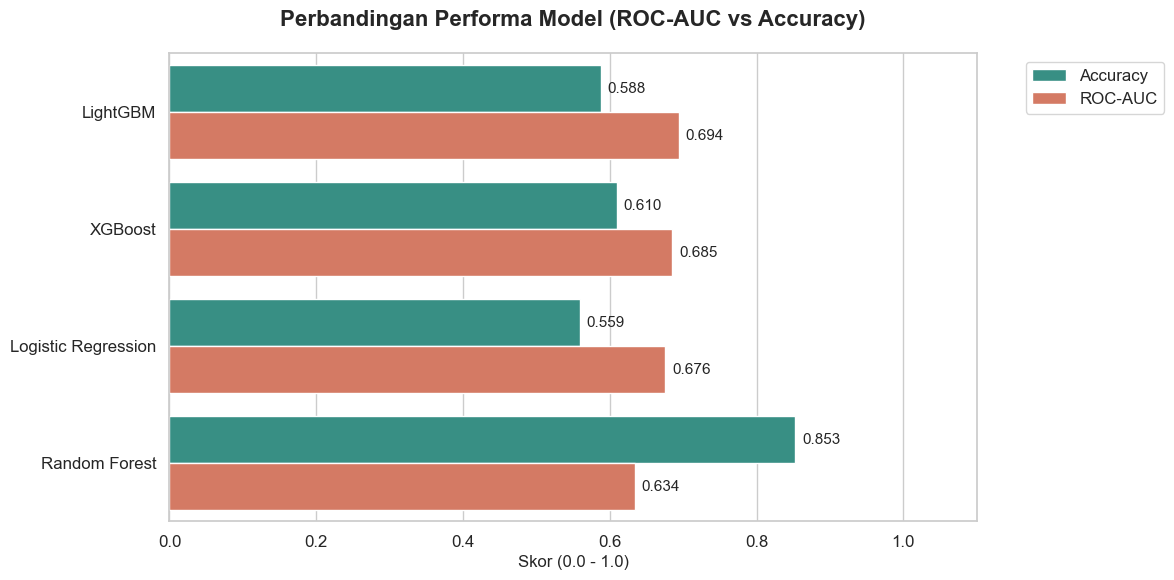

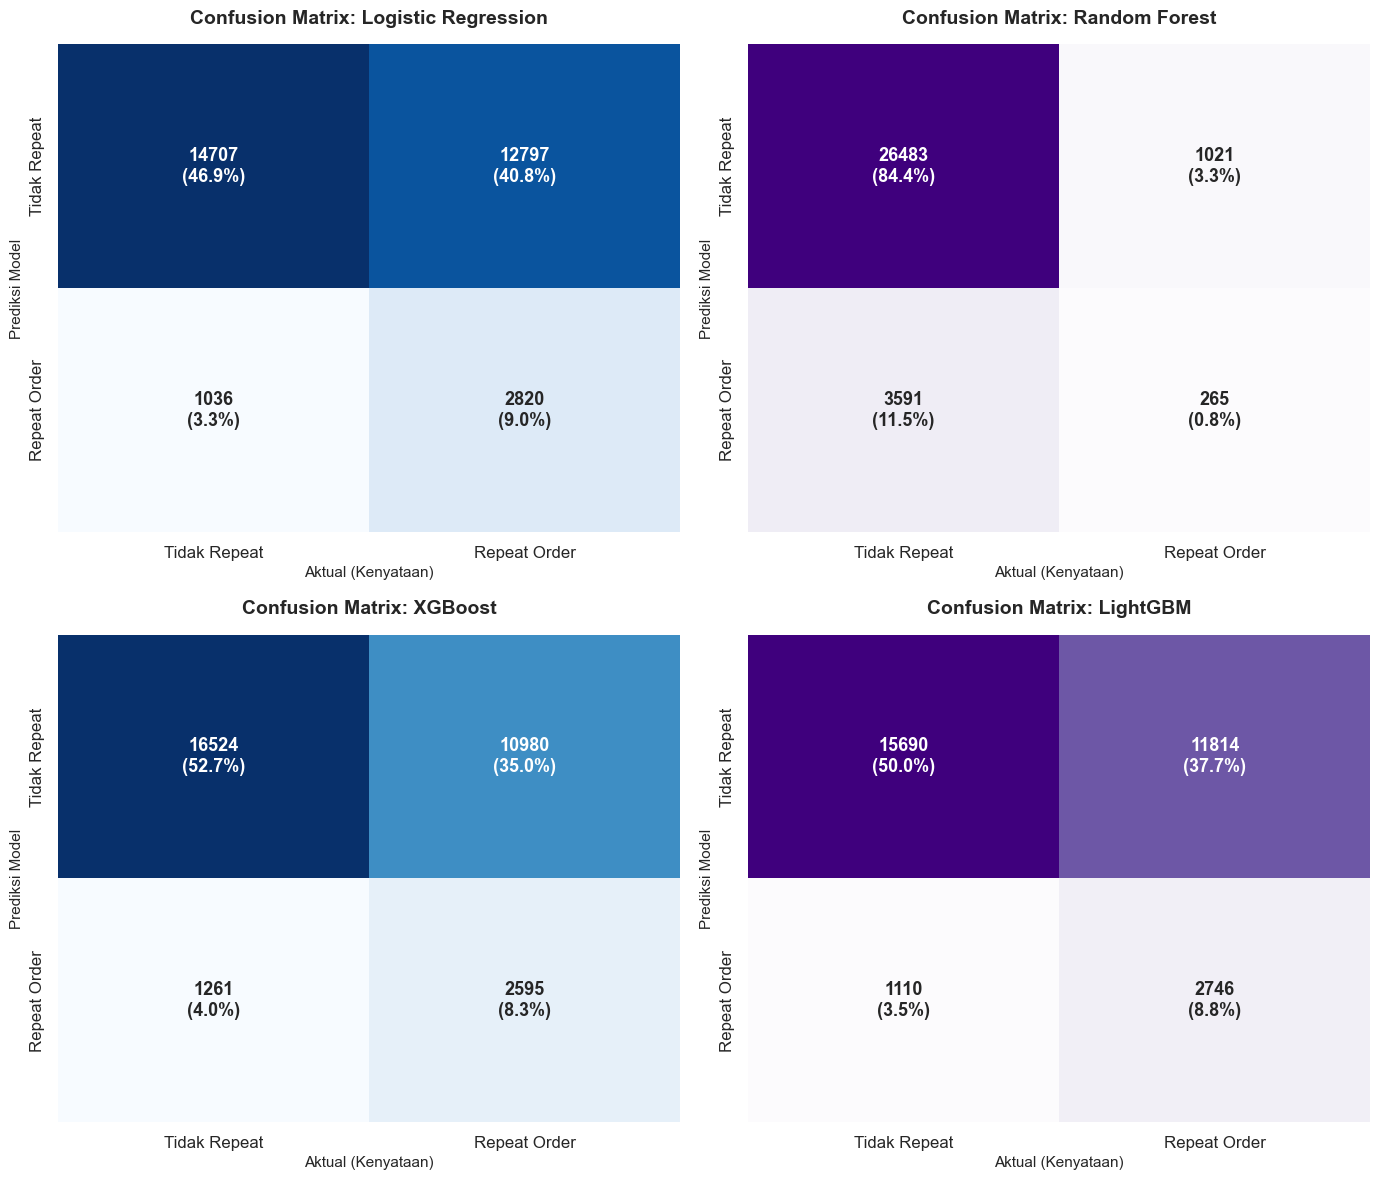

In [25]:
from sklearn.metrics import confusion_matrix, roc_curve

sns.set_theme(style="whitegrid", font_scale=1.1)

warna_model = {'Logistic Regression': '#FF6B6B', 
               'Random Forest': '#4ECDC4', 
               'XGBoost': '#45B7D1', 
               'LightGBM': '#9A8C98'}

#Compare ROC-AUC vs Accuracy 
plt.figure(figsize=(12, 6))
#Dataframe hasil evaluasi model kita masih dalam format lebar (wide), kita ubah dulu ke format panjang (long) agar mudah diplot dengan Seaborn
df_melted = df_results_balanced.melt(id_vars='Model', var_name='Metrik', value_name='Skor')

ax = sns.barplot(x='Skor', y='Model', hue='Metrik', data=df_melted, palette=['#2A9D8F', '#E76F51'])
plt.title('Perbandingan Performa Model (ROC-AUC vs Accuracy)', fontsize=16, fontweight='bold', pad=20)
plt.xlim(0, 1.1) 
plt.xlabel('Skor (0.0 - 1.0)', fontsize=12)
plt.ylabel('')

#Menambahkan anotasi angka di ujung bar
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#Confusion Matrix 
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten() #Mengubah matrix 2x2 menjadi list 1 dimensi agar mudah di-loop

for i, (name, model) in enumerate(models_balanced.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    #Menghitung persentase untuk dianotasi ke dalam heatmap
    cm_perc = cm / np.sum(cm)
    labels = [f"{v1}\n({v2:.1%})" for v1, v2 in zip(cm.flatten(), cm_perc.flatten())]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues' if i%2==0 else 'Purples', 
                ax=axes[i], cbar=False, annot_kws={"size": 13, "weight": "bold"})
    
    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel('Aktual (Kenyataan)', fontsize=11)
    axes[i].set_ylabel('Prediksi Model', fontsize=11)
    axes[i].xaxis.set_ticklabels(['Tidak Repeat', 'Repeat Order'])
    axes[i].yaxis.set_ticklabels(['Tidak Repeat', 'Repeat Order'])

plt.tight_layout()
plt.show()

In [ ]:

for i, (name, model) in enumerate(models_balanced.items()):
    y_pred = model[3].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    #Menghitung persentase untuk dianotasi ke dalam heatmap
    cm_perc = cm / np.sum(cm)
    labels = [f"{v1}\n({v2:.1%})" for v1, v2 in zip(cm.flatten(), cm_perc.flatten())]
    labels = np.asarray(labels).reshape(2,2)
    
    plt.figure(figsize=(14,12))
    plt.set
    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel('Aktual (Kenyataan)', fontsize=11)
    axes[i].set_ylabel('Prediksi Model', fontsize=11)
    axes[i].xaxis.set_ticklabels(['Tidak Repeat', 'Repeat Order'])
    axes[i].yaxis.set_ticklabels(['Tidak Repeat', 'Repeat Order'])

plt.tight_layout()
plt.show()

Random Forest

Model ini hanya berhasil menebak 265 pelanggan (0.8%) padahal jumlah pelanggan repeat order aslinya ada ribuan. Ini membuktikan bahwa meskipun sudah diberi hukuman (class weight), Random Forest tetap terlalu kaku dan takut untuk menebak pelanggan sebagai target prospek.

Logistic Regression 

Model ini berhasil menangkap pelanggan terbanyak yaitu 2.820 orang (9.0%). Tapi, di sisi lain, model ini menghasilkan False Alarm sebanyak 12.797 orang. Artinya, model ini sangat agresif, sehingga membuat tim Sales harus menelepon belasan ribu orang yang sebenarnya tidak tertarik.

XGBoost

XGBoost sedikit lebih pelit (2.595) dalam menangkap pelanggan repeat order dibandingkan LightGBM (2.746) dan Logistic Regression (2.820). Tetapi model XGBoost menghasilkan angka False Alarm-nya yang paling rendah (10.980) di antara tiga model penangkap (selain Random Forest yang memang gagal). LightGBM menyuruh Sales menelpon 11.814 orang salah sasaran, dan Logistic Regression menyuruh menelpon 12.797 orang salah sasaran.

LightGBM

LightGBM berhasil menangkap 2.746 pelanggan yang benar-benar akan beli motor lagi. Angka ini hanya berselisih 74 orang dari Logistic Regression (2.820). Artinya, LightGBM hampir menyentuh batas maksimal dari potensi keuntungan perusahaan. Dibandingkan XGBoost (2.595), LightGBM memberikan ekstra 151 pelanggan setia yang berhasil diselamatkan dari kelolosan.

Kami memilih model ini karena LightGBM mampu memaksimalkan konversi penjualan (menangkap 2.746 pembeli potensial) tanpa harus mengorbankan efisiensi operasional secara membabi buta seperti Logistic Regression. Ditambah dengan arsitektur LightGBM yang sangat ringan dan cepat memproses ratusan ribu baris data secara real-time, model ini sangat siap untuk langsung di-deploy (diaplikasikan) ke dalam sistem produksi IT perusahaan.